In [38]:
import os
import sys
import torch
import yaml
import numpy as np
import pandas as pd
import polars as pl
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

helpers_path = os.path.join('/home/aegis/Titan1/NRAD/data/model_scripts')
sys.path.insert(0, os.path.abspath(helpers_path))
from Classifier_MI import Classifier_MI as Classifier

In [39]:
selection = "ATLAS"


dataset_path = f"Final_Dataset_{selection}"
model_path = f"Models_Extrapolation_{selection}_ver2"
config_path = "configs" 
os.makedirs(model_path, exist_ok=True)


device = torch.device("cpu")
print(f"Using device: {device}")

features_to_train = [
    'met_recalc_pt', 'ht', 
    'mjj', 'ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32'
]

N_ENSEMBLES = 10  

Using device: cpu


In [40]:
def regularize_weights(weights, sigma=3.0):
        mean_w = np.mean(weights)
        std_w = np.std(weights)
        upper_bound = mean_w + (sigma * std_w)
        return np.clip(weights, a_min=0, a_max=upper_bound)

### Training

In [41]:
train_model = False

if train_model:        
    USE_WEIGHTS = True       

    # =====================================================================
    # 2. MAIN TRAINING LOOP OVER CONFIGURED TASKS
    # =====================================================================

    print(f"\n{'='*70}")
    print(f" 🚀 PROCESSING: Reweight in the {selection} Selection")
    print(f"{'='*70}")
    
    # --- A. Split Datasets (The Anti-Leakage Step) ---
    mc_train = pl.read_parquet(f"{dataset_path}/CR_Dataset_Splits/MC_events_train.parquet").to_pandas()
    data_train = pl.read_parquet(f"{dataset_path}/CR_Dataset_Splits/DATA_events_train.parquet").to_pandas()

    print(f"MC Split   -> Train: {len(mc_train)}")
    print(f"Data Split -> Train: {len(data_train)}")

    # --- B. Prepare Arrays for PyTorch ---
    x_mc_train = mc_train[features_to_train].values
    x_data_train = data_train[features_to_train].values

    y_mc_train = np.zeros((x_mc_train.shape[0], 1))
    y_data_train = np.ones((x_data_train.shape[0], 1))

    input_x = np.vstack([x_data_train, x_mc_train])
    input_y = np.vstack([y_data_train, y_mc_train])

    # --- C. Handle Optional Weights ---
    if USE_WEIGHTS:
        print("Using sample weights for training.")
        w_data = np.ones((x_data_train.shape[0], 1))
        # Ensure 'final_weight' exists or fall back to 'raw_weights'
        weight_col = 'final_weight'
        w_mc = mc_train[weight_col].values.reshape(-1, 1)
        input_w = np.vstack([w_data, w_mc])
    else:
        print("Training WITHOUT sample weights.")
        input_w = None

    # --- D. Ensemble Training ---
    with open(f"{config_path}/reweight_physics.yml", 'r') as stream:
        params_rw = yaml.safe_load(stream)

    for i in range(N_ENSEMBLES):
        print(f"\n--- Training Ensemble {i+1}/{N_ENSEMBLES} ---")
        
        NN_rw = Classifier(
            n_inputs=len(features_to_train), 
            layers=params_rw.get("layers"), 
            learning_rate=0.0001, 
            device=device
        )

        current_seed = 42 + i*7

        # Tag the model with the run_name (e.g., "reweight_Combined_CRs_ens0")
        model_name = f"reweight_ens{i}"
        
        NN_rw.train(
            input_x=input_x, 
            input_y=input_y, 
            weights=input_w, 
            save_model=True, 
            batch_size=params_rw.get("batch_size"), 
            n_epochs=params_rw.get("n_epochs"), 
            model_name=model_name, 
            outdir=model_path,
            early_stop=True,
            seed=current_seed 
        )
print("\n🎉 Reweight training phase complete!")


🎉 Reweight training phase complete!


### Loss Evaluation

In [42]:
loss_path = os.path.join(model_path, "loss_data")
print(f"Loss data read from: {loss_path}")

Loss data read from: Models_Extrapolation_ATLAS_ver2/loss_data


In [43]:
all_train_losses = []
all_val_losses = []

for i in range(N_ENSEMBLES):
    model_name = f"reweight_ens{i}"
    loss_file = os.path.join(loss_path, f"{model_name}_loss.npz")
    
    if os.path.exists(loss_file):
        with np.load(loss_file) as loss_data:
            all_train_losses.append(loss_data['train_loss'])
            all_val_losses.append(loss_data['val_loss'])
        print(f"Loaded loss data for {model_name}")
    else:
        print(f"Warning: Loss file {loss_file} not found.")

# If no files were found, exit early
if not all_train_losses:
    raise FileNotFoundError("No loss files were found. Please check your path and model names.")


max_epochs = max(len(loss) for loss in all_train_losses)

padded_train_losses = []
padded_val_losses = []

for train_loss, val_loss in zip(all_train_losses, all_val_losses):
    pad_length = max_epochs - len(train_loss)
    
    # FORWARD FILLING (Recommended): Carries the final loss value forward
    padded_train_losses.append(np.pad(train_loss, (0, pad_length), mode='edge'))
    padded_val_losses.append(np.pad(val_loss, (0, pad_length), mode='edge'))
    
    # ALTERNATIVE (NaN Padding): If you prefer models to drop out of the average completely
    # padded_train_losses.append(np.pad(train_loss, (0, pad_length), constant_values=np.nan))
    # padded_val_losses.append(np.pad(val_loss, (0, pad_length), constant_values=np.nan))

# Convert to 2D numpy arrays
all_train_losses = np.array(padded_train_losses)
all_val_losses = np.array(padded_val_losses)

Loaded loss data for reweight_ens0
Loaded loss data for reweight_ens1
Loaded loss data for reweight_ens2
Loaded loss data for reweight_ens3
Loaded loss data for reweight_ens4
Loaded loss data for reweight_ens5
Loaded loss data for reweight_ens6
Loaded loss data for reweight_ens7
Loaded loss data for reweight_ens8
Loaded loss data for reweight_ens9


In [44]:
# ==========================================
# 4. Calculate Statistics
# ==========================================
# Note: If you switch to the NaN padding alternative above, 
# you MUST change np.mean to np.nanmean and np.std to np.nanstd here.
mean_train = np.mean(all_train_losses, axis=0)
std_train = np.std(all_train_losses, axis=0)

mean_val = np.mean(all_val_losses, axis=0)
std_val = np.std(all_val_losses, axis=0)

# Create the master x-axis
epochs_array = np.arange(max_epochs)

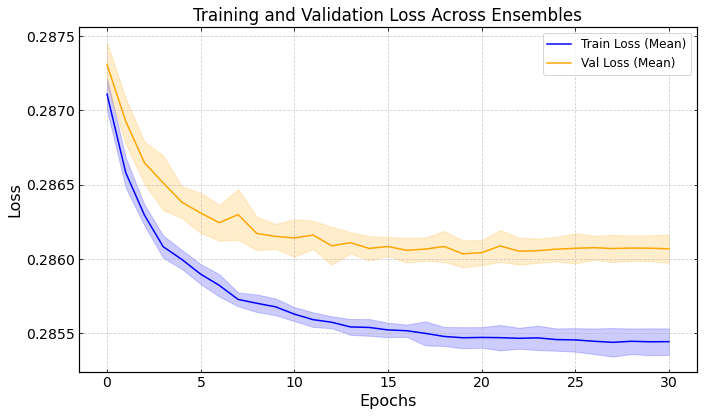

In [45]:
# ==========================================
# 5. Plotting
# ==========================================
plt.figure(figsize=(10, 6))

# Plot Training Loss (Blue)
plt.plot(epochs_array, mean_train, color='blue', label='Train Loss (Mean)')
plt.fill_between(
    epochs_array, 
    mean_train - std_train, 
    mean_train + std_train, 
    color='blue', 
    alpha=0.2
)

# Plot Validation Loss (Orange)
plt.plot(epochs_array, mean_val, color='orange', label='Val Loss (Mean)')
plt.fill_between(
    epochs_array, 
    mean_val - std_val, 
    mean_val + std_val, 
    color='orange', 
    alpha=0.2
)

# Formatting
plt.title('Training and Validation Loss Across Ensembles')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Display the plot
plt.tight_layout()
plt.show()

### Quick Check

In [46]:
def reweight_weights(model, df_mc_pd, feature_list, ensemble_idx):
    x_test_mc = df_mc_pd[feature_list].values
    w_prob = model.evaluation(x_test_mc)
    w = (w_prob / (1 - w_prob)).flatten()

    df_mc_pd[f'reweight_weights_ens{ensemble_idx}'] = w

    return df_mc_pd    

#### Control Region

In [48]:
mc_test = pl.read_parquet(f"{dataset_path}/CR_Dataset_Splits/MC_events_test.parquet").to_pandas()
data_test = pl.read_parquet(f"{dataset_path}/CR_Dataset_Splits/DATA_events_test.parquet").to_pandas()
print(f"CR MC Split   -> Test: {len(mc_test)}")
print(f"CR Data Split -> Test: {len(data_test)}")

CR MC Split   -> Test: 84161
CR Data Split -> Test: 21983


In [49]:
for i in range(N_ENSEMBLES):
    model_name = f"reweight_ens{i}"
    model_file = os.path.join(model_path, f"{model_name}.pt")
    
    if os.path.exists(model_file):
        print(f"\nApplying {model_name} to reweight MC datasets...")
        model = torch.load(model_file, map_location=device, weights_only=False)
        mc_test = reweight_weights(model, mc_test, features_to_train, i)
    else:
        print(f"Warning: Model file {model_file} not found. Skipping this ensemble.")


Applying reweight_ens0 to reweight MC datasets...

Applying reweight_ens1 to reweight MC datasets...

Applying reweight_ens2 to reweight MC datasets...

Applying reweight_ens3 to reweight MC datasets...

Applying reweight_ens4 to reweight MC datasets...

Applying reweight_ens5 to reweight MC datasets...

Applying reweight_ens6 to reweight MC datasets...

Applying reweight_ens7 to reweight MC datasets...

Applying reweight_ens8 to reweight MC datasets...

Applying reweight_ens9 to reweight MC datasets...


In [50]:
mc_test["reweight_weights_mean"] = mc_test[[f'reweight_weights_ens{i}' for i in range(N_ENSEMBLES)]].mean(axis=1)
mc_test["reweight_weights_std"] = mc_test[[f'reweight_weights_ens{i}' for i in range(N_ENSEMBLES)]].std(axis=1)


Generating closure plot for feature: met_recalc_pt
Metrics for met_recalc_pt in CR:
  Nominal MC -> chi2/ndf: 1150.08/14 (p=0.0000) | Norm W1: 0.0078
  Reweighted -> chi2/ndf: 650.84/19 (p=0.0000) | Norm W1: 0.0039
----------------------------------------------------------------------


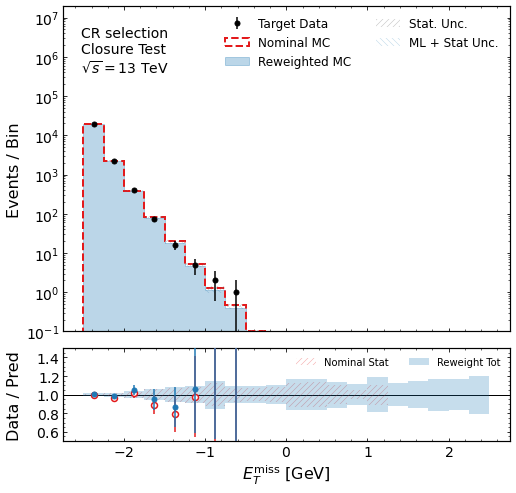


Generating closure plot for feature: ht
Metrics for ht in CR:
  Nominal MC -> chi2/ndf: 115.49/13 (p=0.0000) | Norm W1: 0.0110
  Reweighted -> chi2/ndf: 598.25/19 (p=0.0000) | Norm W1: 0.0042
----------------------------------------------------------------------


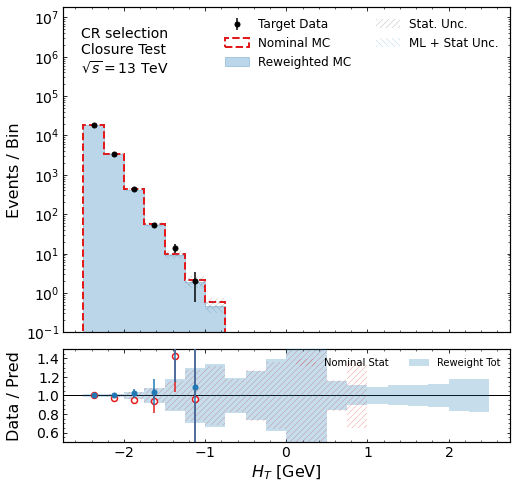


Generating closure plot for feature: mjj
Metrics for mjj in CR:
  Nominal MC -> chi2/ndf: 93.17/15 (p=0.0000) | Norm W1: 0.0905
  Reweighted -> chi2/ndf: 324.66/19 (p=0.0000) | Norm W1: 0.0408
----------------------------------------------------------------------


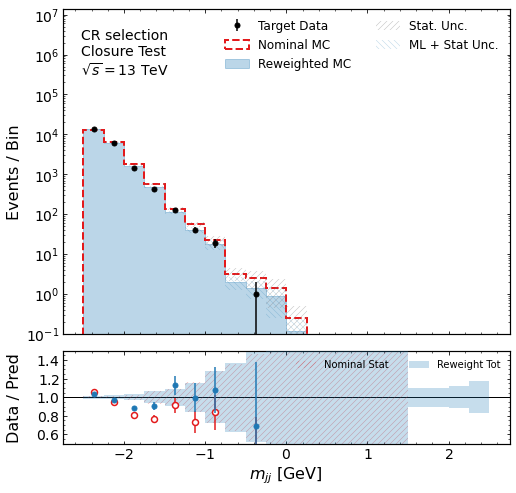


Generating closure plot for feature: ljet1_tau21
Metrics for ljet1_tau21 in CR:
  Nominal MC -> chi2/ndf: 70.09/19 (p=0.0000) | Norm W1: 0.0391
  Reweighted -> chi2/ndf: 19.23/19 (p=0.4420) | Norm W1: 0.0216
----------------------------------------------------------------------


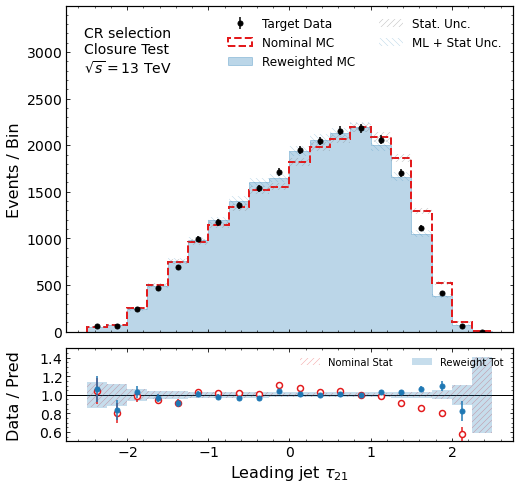


Generating closure plot for feature: ljet1_tau32
Metrics for ljet1_tau32 in CR:
  Nominal MC -> chi2/ndf: 229.29/19 (p=0.0000) | Norm W1: 0.0914
  Reweighted -> chi2/ndf: 35.47/19 (p=0.0123) | Norm W1: 0.0238
----------------------------------------------------------------------


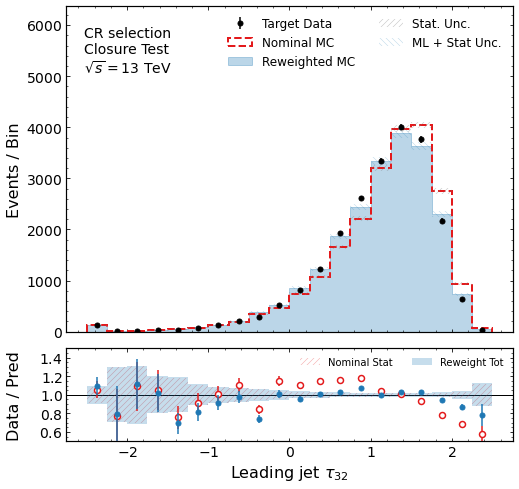


Generating closure plot for feature: ljet2_tau21
Metrics for ljet2_tau21 in CR:
  Nominal MC -> chi2/ndf: 68.23/19 (p=0.0000) | Norm W1: 0.0362
  Reweighted -> chi2/ndf: 15.87/19 (p=0.6662) | Norm W1: 0.0101
----------------------------------------------------------------------


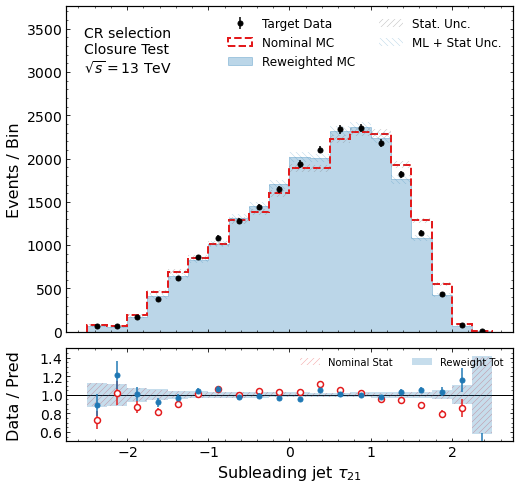


Generating closure plot for feature: ljet2_tau32
Metrics for ljet2_tau32 in CR:
  Nominal MC -> chi2/ndf: 118.45/19 (p=0.0000) | Norm W1: 0.0645
  Reweighted -> chi2/ndf: 25.09/19 (p=0.1578) | Norm W1: 0.0243
----------------------------------------------------------------------


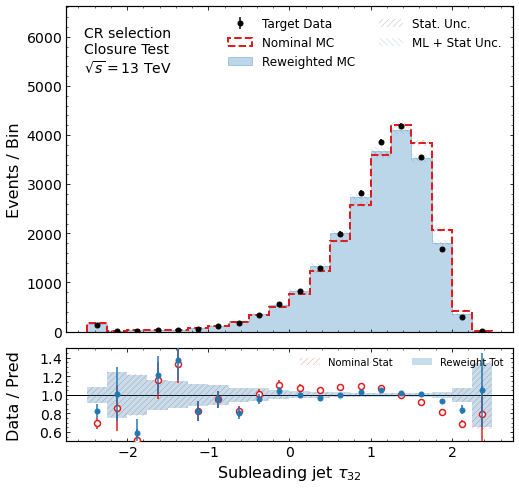

In [51]:
df_data_cr = pl.from_pandas(data_test)
df_mc_cr = pl.from_pandas(mc_test)

for feature in features_to_train:
    print(f"\nGenerating closure plot for feature: {feature}")
    plot_closure("CR", df_mc_cr, df_data_cr, feature)

#### Signal Region

In [56]:
mc_sr = pl.read_parquet(f"{dataset_path}/MC_SR_clean.parquet").to_pandas()
data_sr = pl.read_parquet(f"{dataset_path}/DATA_SR_clean.parquet").to_pandas()
print(f"SR MC Split   -> Test: {len(mc_sr)}")
print(f"SR Data Split -> Test: {len(data_sr)}")

SR MC Split   -> Test: 528846
SR Data Split -> Test: 188757


In [53]:
for i in range(N_ENSEMBLES):
    model_name = f"reweight_ens{i}"
    model_file = os.path.join(model_path, f"{model_name}.pt")
    
    if os.path.exists(model_file):
        print(f"\nApplying {model_name} to reweight SR datasets...")
        model = torch.load(model_file, map_location=device, weights_only=False)
        mc_sr = reweight_weights(model, mc_sr, features_to_train, i)
    else:
        print(f"Warning: Model file {model_file} not found. Skipping this ensemble.")


Applying reweight_ens0 to reweight SR datasets...

Applying reweight_ens1 to reweight SR datasets...

Applying reweight_ens2 to reweight SR datasets...

Applying reweight_ens3 to reweight SR datasets...

Applying reweight_ens4 to reweight SR datasets...

Applying reweight_ens5 to reweight SR datasets...

Applying reweight_ens6 to reweight SR datasets...

Applying reweight_ens7 to reweight SR datasets...

Applying reweight_ens8 to reweight SR datasets...

Applying reweight_ens9 to reweight SR datasets...


In [54]:
mc_sr["reweight_weights_mean"] = mc_sr[[f'reweight_weights_ens{i}' for i in range(N_ENSEMBLES)]].mean(axis=1)
mc_sr["reweight_weights_std"] = mc_sr[[f'reweight_weights_ens{i}' for i in range(N_ENSEMBLES)]].std(axis=1)


Generating closure plot for feature: met_recalc_pt
Metrics for met_recalc_pt in SR:
  Nominal MC -> chi2/ndf: 37.90/4 (p=0.0000) | Norm W1: 0.0029
  Reweighted -> chi2/ndf: 29.65/4 (p=0.0000) | Norm W1: 0.0081
----------------------------------------------------------------------


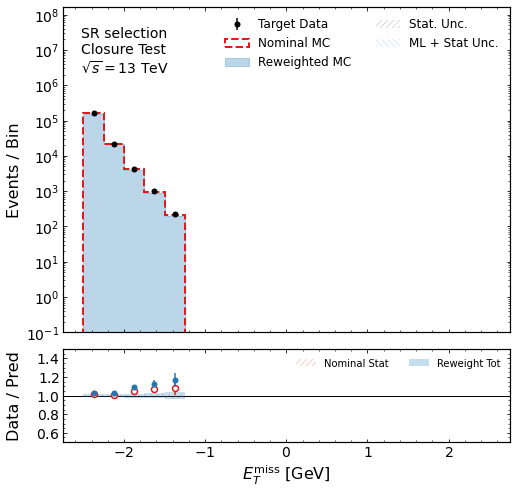


Generating closure plot for feature: ht
Metrics for ht in SR:
  Nominal MC -> chi2/ndf: 34.79/6 (p=0.0000) | Norm W1: 0.0029
  Reweighted -> chi2/ndf: 42.41/6 (p=0.0000) | Norm W1: 0.0154
----------------------------------------------------------------------


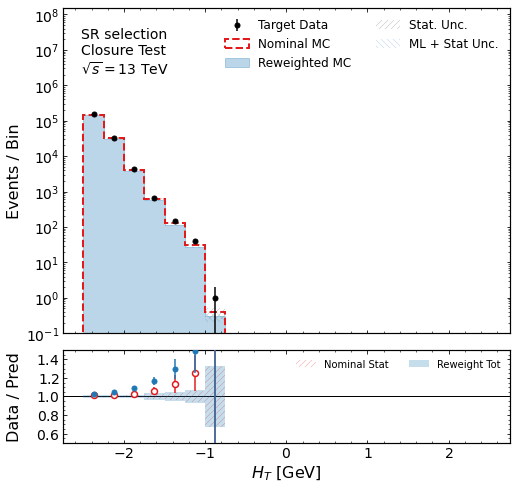


Generating closure plot for feature: mjj
Metrics for mjj in SR:
  Nominal MC -> chi2/ndf: 396.64/13 (p=0.0000) | Norm W1: 0.0640
  Reweighted -> chi2/ndf: 22.94/13 (p=0.0424) | Norm W1: 0.0162
----------------------------------------------------------------------


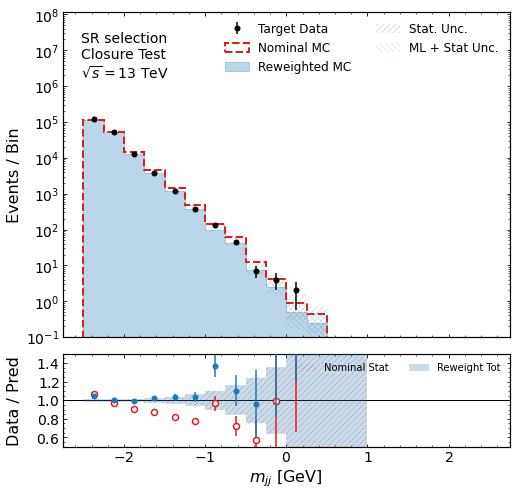


Generating closure plot for feature: ljet1_tau21
Metrics for ljet1_tau21 in SR:
  Nominal MC -> chi2/ndf: 789.29/19 (p=0.0000) | Norm W1: 0.0555
  Reweighted -> chi2/ndf: 65.14/19 (p=0.0000) | Norm W1: 0.0051
----------------------------------------------------------------------


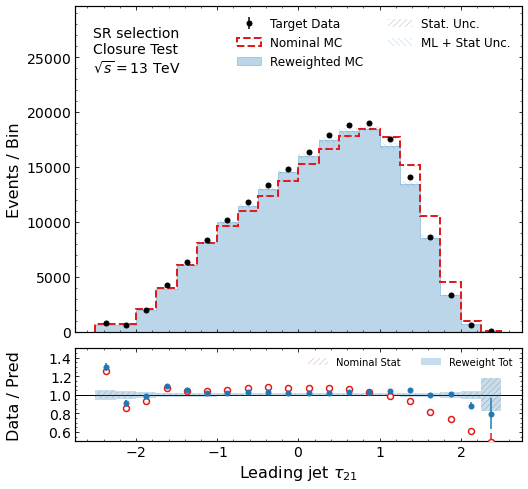


Generating closure plot for feature: ljet1_tau32
Metrics for ljet1_tau32 in SR:
  Nominal MC -> chi2/ndf: 1625.54/19 (p=0.0000) | Norm W1: 0.0902
  Reweighted -> chi2/ndf: 76.22/19 (p=0.0000) | Norm W1: 0.0135
----------------------------------------------------------------------


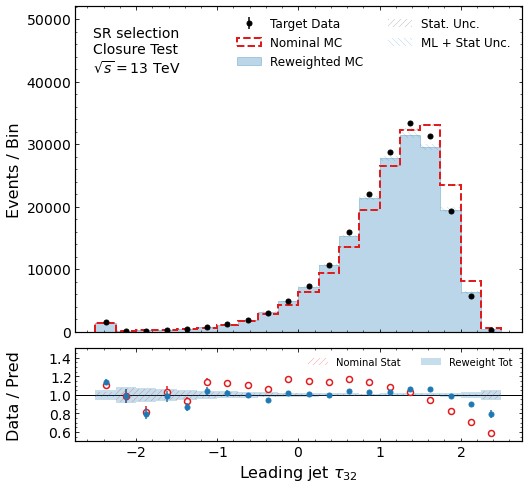


Generating closure plot for feature: ljet2_tau21
Metrics for ljet2_tau21 in SR:
  Nominal MC -> chi2/ndf: 878.48/19 (p=0.0000) | Norm W1: 0.0559
  Reweighted -> chi2/ndf: 77.08/19 (p=0.0000) | Norm W1: 0.0220
----------------------------------------------------------------------


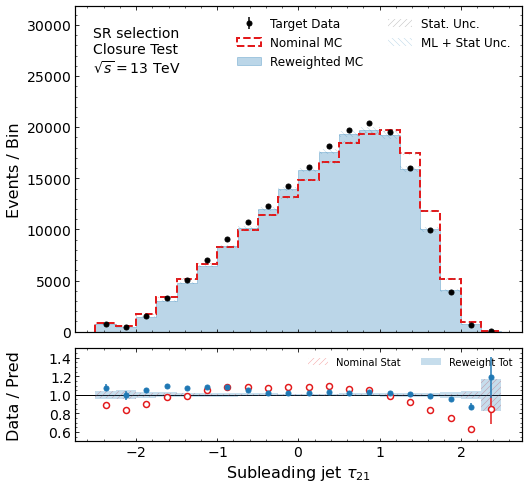


Generating closure plot for feature: ljet2_tau32
Metrics for ljet2_tau32 in SR:
  Nominal MC -> chi2/ndf: 1399.33/19 (p=0.0000) | Norm W1: 0.0771
  Reweighted -> chi2/ndf: 93.75/19 (p=0.0000) | Norm W1: 0.0231
----------------------------------------------------------------------


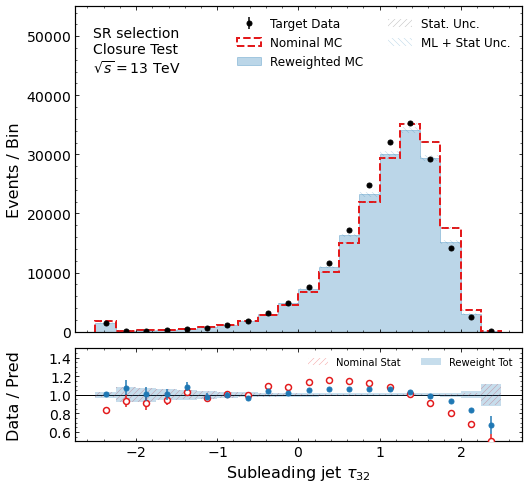

In [55]:
df_data_sr = pl.from_pandas(data_sr)
df_mc_sr = pl.from_pandas(mc_sr)

for feature in features_to_train:
    print(f"\nGenerating closure plot for feature: {feature}")
    plot_closure("SR", df_mc_sr, df_data_sr, feature)